# Advanced layer types -- Image Classification

## 0. Import packages and modules

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import pathlib

import sklearn
import torch
from torch import nn

from torchinfo import summary
#import torchmetrics

print(sklearn.__version__)
print(torch.__version__)

1.6.1
2.8.0


In [2]:
# print GPU info

print(f"CUDA available: {torch.cuda.is_available()}")

print(f"Num GPUs Available: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"{torch.cuda.get_device_name(device)}: temp: {torch.cuda.temeperature(device)} °C, power draw: {torch.cuda.power_draw()} mW, clock rate: {torch.cuda.clock_rate}")
else:
    device = torch.device("cpu")

CUDA available: False
Num GPUs Available: 0


## 1. Formulate / Outline the problem: Image classification

In [3]:
DATA_FOLDER = pathlib.Path(f"{os.environ['HOME']}/Downloads/DollarStreet10") # change to location where you stored the data
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

## 2. Identify inputs and outputs

In [4]:
train_images.shape

(878, 64, 64, 3)

In [5]:
train_images.min(), train_images.max()

(np.int32(0), np.int32(255))

In [6]:
train_labels.shape

(878,)

In [7]:
train_labels.min(), train_labels.max()

(np.int64(0), np.int64(9))

## 3. Prepare data

In [8]:
class DollarStreetDataset(torch.utils.data.Dataset):
    def __init__(self, root, train=True):
        prefix = "test"
        if train == True:
            prefix = "train"
        self.images = np.load(root / f'{prefix}_images.npy') / 255.
        self.labels = np.load(root / f'{prefix}_labels.npy')
        
    def __getitem__(self, idx):
        x = torch.permute(torch.tensor(self.images[idx], dtype=torch.float), (2, 0, 1))
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y
        
    def __len__(self):
        return self.images.shape[0]

train_ds = DollarStreetDataset(root=DATA_FOLDER, train=True)
val_ds = DollarStreetDataset(root=DATA_FOLDER, train=False)

## 4. Build a pretrained model

In [9]:
class DollarStreetModelSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(50*60*60, 10),
        )
    def forward(self, x):
        return self.s(x)

model = DollarStreetModelSmall()

In [34]:
summary(model, input_size=(1, 3, 64, 64))

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Sequential: 1, Conv2d: 2, ReLU: 2, MaxPool2d: 2, Sequential: 1, Sequential: 2, Conv2d: 3, ReLU: 3, MaxPool2d: 3, Dropout: 2, Flatten: 2]

In [11]:
class DollarStreetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(14*14*50, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        return self.s(x)

model = DollarStreetModel()
summary(model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
DollarStreetModel                        [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 50, 62, 62]           1,400
│    └─ReLU: 2-2                         [1, 50, 62, 62]           --
│    └─MaxPool2d: 2-3                    [1, 50, 31, 31]           --
│    └─Conv2d: 2-4                       [1, 50, 29, 29]           22,550
│    └─ReLU: 2-5                         [1, 50, 29, 29]           --
│    └─MaxPool2d: 2-6                    [1, 50, 14, 14]           --
│    └─Flatten: 2-7                      [1, 9800]                 --
│    └─Linear: 2-8                       [1, 50]                   490,050
│    └─ReLU: 2-9                         [1, 50]                   --
│    └─Linear: 2-10                      [1, 10]                   510
Total params: 514,510
Trainable params: 514,510
Non-trainable params: 0


## 5. Choose a loss function and optimizer

In [12]:
optim = torch.optim.Adam(model.parameters(), lr=0.003)
crit = torch.nn.CrossEntropyLoss()

## 6. Train the model

In [13]:
def train(dl, model, loss_fn, optimizer, device=torch.device("cuda:0")):
    model = model.to(device)
    model.train()
    avg_loss, correct = 0., 0.
    for step, (x, y) in (enumerate(pbar:=tqdm(dl))):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        avg_loss += loss.item()
        pbar.set_description(f"Loss: {(loss.item()):>7f}")
        loss.backward()
        optimizer.step()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    avg_loss /= len(dl)
    correct /= len(dl.dataset)
    return avg_loss, correct

def test(dl, model, loss_fn, device=torch.device("cuda:0")):
    model = model.to(device)
    model.eval()
    loss, correct = 0., 0.
    with torch.no_grad():
        for step, (x, y) in enumerate(dl):
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    loss /= len(dl)
    correct /= (len(dl.dataset))
    print(f"Test accuracy: {(100 * correct):>0.1f}%, Avg loss: {loss:>8f}")
    return loss, correct


In [14]:
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=1, shuffle=False)

In [15]:
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
for epoch in range(50):
    print(f"Epoch {epoch}:")
    loss, accuracy = train(train_dl, model, crit, optim, device=device)
    val_loss, val_accuracy = test(train_dl, model, crit, device=device)

    for k, v in [("loss", loss), ("val_loss", val_loss), ("accuracy", accuracy), ("val_accuracy", val_accuracy)]:
        history[k].append(v)

Epoch 0:


Loss: 2.183861: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 18.44it/s]


Test accuracy: 18.6%, Avg loss: 2.231252
Epoch 1:


Loss: 2.104381: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 19.10it/s]


Test accuracy: 22.4%, Avg loss: 2.145825
Epoch 2:


...

Test accuracy: 99.9%, Avg loss: 0.010058
Epoch 48:


Loss: 0.001123: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 18.97it/s]


Test accuracy: 99.9%, Avg loss: 0.006380
Epoch 49:


Loss: 0.001870: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 19.31it/s]


Test accuracy: 99.9%, Avg loss: 0.011138


## 7. Perform a Prediction/Classification

## 8. Measure performance

In [16]:
def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history(dict): dictionary containing metrics over the course of training
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")


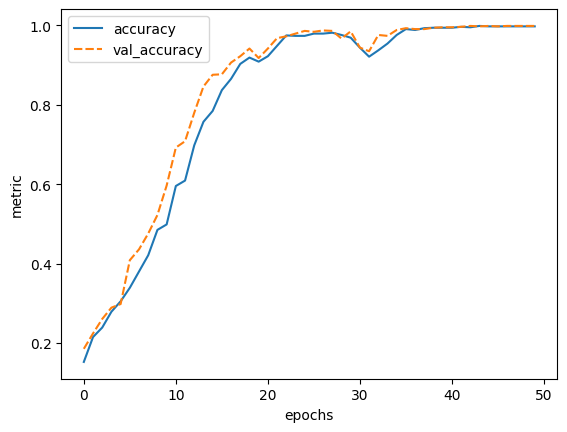

In [17]:
plot_history(history, ['accuracy', 'val_accuracy'])

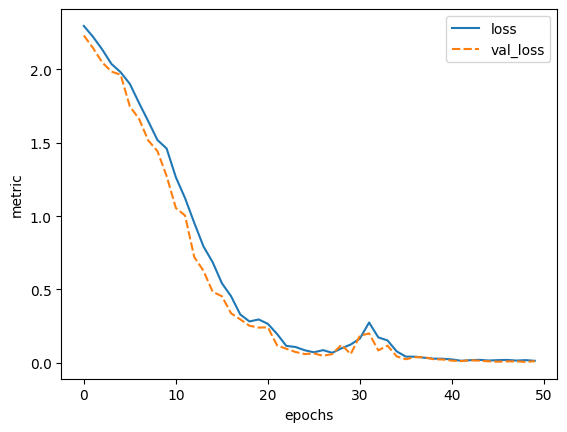

In [18]:
plot_history(history, ['loss', 'val_loss'])

**Comparison with a network with only dense layers**

In [19]:
class DenseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Flatten(),
            nn.Linear(12288, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        return self.s(x)

dense_model = DenseModel()
summary(dense_model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
DenseModel                               [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 12288]                --
│    └─Linear: 2-2                       [1, 50]                   614,450
│    └─ReLU: 2-3                         [1, 50]                   --
│    └─Linear: 2-4                       [1, 50]                   2,550
│    └─ReLU: 2-5                         [1, 50]                   --
│    └─Linear: 2-6                       [1, 10]                   510
Total params: 617,510
Trainable params: 617,510
Non-trainable params: 0
Total mult-adds (M): 0.62
Input size (MB): 0.05
Forward/backward pass size (MB): 0.00
Params size (MB): 2.47
Estimated Total Size (MB): 2.52

In [20]:
dense_optim = torch.optim.Adam(dense_model.parameters(), lr=0.001)
dense_crit = torch.nn.CrossEntropyLoss()
dense_history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=1, shuffle=False)
for epoch in range(30):
    print(f"Epoch {epoch}:")
    loss, accuracy = train(train_dl, dense_model, dense_crit, dense_optim, device=device)
    val_loss, val_accuracy = test(train_dl, dense_model, dense_crit, device=device)

    for k, v in [("loss", loss), ("val_loss", val_loss), ("accuracy", accuracy), ("val_accuracy", val_accuracy)]:
        dense_history[k].append(v)



Epoch 0:


Loss: 2.107376: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 269.55it/s]


Test accuracy: 19.2%, Avg loss: 2.319409
Epoch 1:


Loss: 2.318200: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 308.44it/s]


Test accuracy: 19.6%, Avg loss: 2.209114
Epoch 2:


...

Test accuracy: 52.7%, Avg loss: 1.414299
Epoch 28:


Loss: 1.626657: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 403.67it/s]


Test accuracy: 56.4%, Avg loss: 1.305961
Epoch 29:


Loss: 1.114523: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 372.85it/s]


Test accuracy: 52.7%, Avg loss: 1.348208


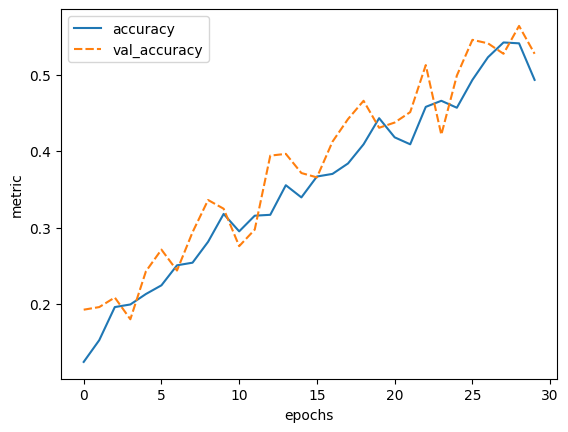

In [21]:
plot_history(dense_history, ['accuracy', 'val_accuracy'])

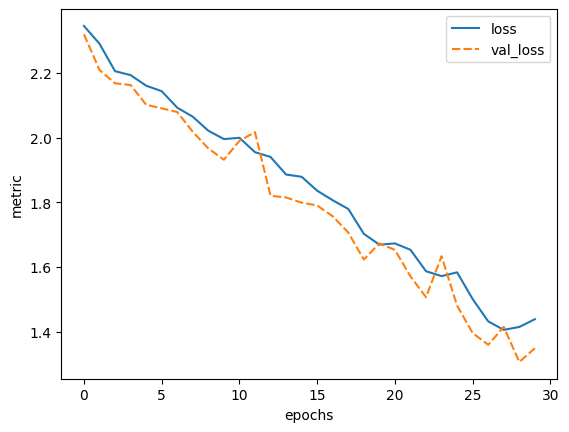

In [22]:
plot_history(dense_history, ['loss', 'val_loss'])

## 9. Refine the model

In [30]:
class ModelDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),  # This is new!
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),  # This is new!
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),  # This is new!
            nn.Flatten(),
            nn.Linear(1800, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        return self.s(x)

dropout_model = ModelDropout()
summary(dropout_model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
ModelDropout                             [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 50, 62, 62]           1,400
│    └─ReLU: 2-2                         [1, 50, 62, 62]           --
│    └─MaxPool2d: 2-3                    [1, 50, 31, 31]           --
│    └─Dropout: 2-4                      [1, 50, 31, 31]           --
│    └─Conv2d: 2-5                       [1, 50, 29, 29]           22,550
│    └─ReLU: 2-6                         [1, 50, 29, 29]           --
│    └─MaxPool2d: 2-7                    [1, 50, 14, 14]           --
│    └─Dropout: 2-8                      [1, 50, 14, 14]           --
│    └─Conv2d: 2-9                       [1, 50, 12, 12]           22,550
│    └─ReLU: 2-10                        [1, 50, 12, 12]           --
│    └─MaxPool2d: 2-11                   [1, 50, 6, 6]             --
│   

In [31]:
dropout_optim = torch.optim.Adam(dropout_model.parameters(), lr=1e-4)
dropout_crit = torch.nn.CrossEntropyLoss()
dropout_history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=1, shuffle=False)
for epoch in range(20):
    print(f"Epoch {epoch}:")
    loss, accuracy = train(train_dl, dropout_model, dropout_crit, dropout_optim, device)
    val_loss, val_accuracy = test(train_dl, dropout_model, dropout_crit, device)

    for k, v in [("loss", loss), ("val_loss", val_loss), ("accuracy", accuracy), ("val_accuracy", val_accuracy)]:
        dropout_history[k].append(v)

Epoch 0:


Loss: 2.300934: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 14.91it/s]


Test accuracy: 12.8%, Avg loss: 2.304160
Epoch 1:


Loss: 2.298812: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 15.35it/s]


Test accuracy: 12.8%, Avg loss: 2.302610
Epoch 2:


...

Test accuracy: 21.0%, Avg loss: 2.225573
Epoch 18:


Loss: 2.171686: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 15.49it/s]


Test accuracy: 21.4%, Avg loss: 2.212212
Epoch 19:


Loss: 2.219311: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 15.57it/s]


Test accuracy: 21.3%, Avg loss: 2.207276


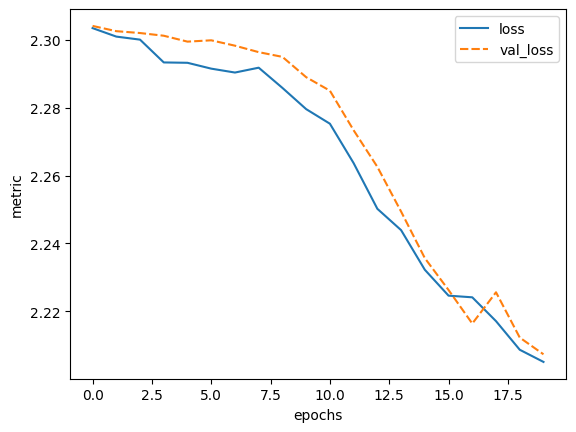

In [32]:
plot_history(dropout_history, ['loss', 'val_loss'])

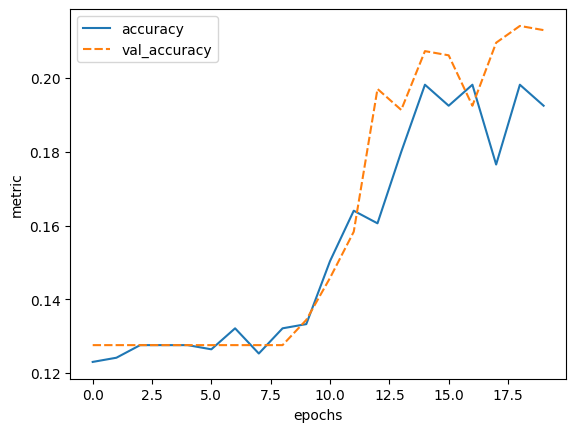

In [33]:
plot_history(dropout_history, ['accuracy', 'val_accuracy'])

In [27]:
class HPModel(nn.Module):
    def __init__(self, dropout_rate, n_layers):
        super().__init__()
        self.in_layer = nn.Sequential(nn.Conv2d(3, 50, 3), nn.ReLU(), nn.MaxPool2d(2))
        self.hidden_layers = nn.Sequential(*[nn.Sequential(nn.Conv2d(50, 50, 3), nn.ReLU(), nn.MaxPool2d(2)) for n in range(n_layers-1)])
        n_features_after_flatten = 64
        for n in range(n_layers):
            n_features_after_flatten = (n_features_after_flatten - 2)//2
        n_features_after_flatten ** 2 * 50
        self.head = nn.Sequential(nn.Dropout(dropout_rate), nn.Flatten(), nn.Linear(n_features_after_flatten , 50), nn.ReLU(), nn.Linear(50, 10))
    def forward(self, x):
        x = self.in_layer(x)
        x = self.hidden_layers(x)
        x = self.head(x)
        return x

**NOTE**: here we need to install keras_tuner. In LUMI, it comes preinstalled. Otherwise run the following inside a Jupyter cell: 

```
!python3 -m pip install keras_tuner
```

In [28]:
n_layers_grid = [1, 2]
dropout_rate_grid = np.linspace(.2, .8, 3)

best = None
best_loss = float("inf")
best_model = None
histories = {}
trial = 0



for n_layers in n_layers_grid:
    for p in dropout_rate_grid:
        train_dl = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
        val_dl = torch.utils.data.DataLoader(val_ds, batch_size=1, shuffle=False)
        model = HPModel(p, n_layers)
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        crit = torch.nn.CrossEntropyLoss()
        histories[n_layers, p] = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
        for epoch in range(20):
            loss, accuracy = train(train_dl, dense_model, crit, optim, device)
            val_loss, val_accuracy = test(train_dl, dense_model, crit, device)

            if val_loss < best_loss:
                best_loss = val_loss
                best = (n_layers, p)
                best_model = model

            for k, v in [("loss", loss), ("val_loss", val_loss), ("accuracy", accuracy), ("val_accuracy", val_accuracy)]:
                histories[n_layers, p][k].append(v)
        print(f"trial {trial}: params: {n_layers}, {p}; best: {best_loss} at {best}")
        trial += 1


Loss: 0.955666: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 501.22it/s]


Test accuracy: 52.7%, Avg loss: 1.349706


Loss: 1.406999: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 511.24it/s]


Test accuracy: 52.7%, Avg loss: 1.343367


Loss: 1.408512: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 586.35it/s]


...

Test accuracy: 52.7%, Avg loss: 1.335259


Loss: 1.243192: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 613.20it/s]


Test accuracy: 52.7%, Avg loss: 1.343496


Loss: 1.216784: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 588.93it/s]


Test accuracy: 52.7%, Avg loss: 1.353831
trial 5: params: 2, 0.8; best: 1.3333770824330193 at (2, np.float64(0.2))


In [29]:
print(f"best val loss: {best_loss} at {best}")
print(trial)

best val loss: 1.3333770824330193 at (2, np.float64(0.2))
6


## 10. Share model

In [26]:
torch.save(best_model.state_dict(), "image_classifcation.pth")

In [37]:
print(len(train_ds))
print(len(val_ds))
print(len(train_dl))
print(len(val_dl))

878
293
28
293
